# Project 1: Spotting a faulty cogwheel

### Step 1. Importing the libraries and loading the audio files

In [19]:
import numpy as np, matplotlib.pyplot as plt, librosa as lib, os, scipy.signal as sc

In [3]:
folder1 = 'Z01/'
folder2 = 'Z05/'

# Getting list of full paths with folder info
file_paths = [
    os.path.join(folder1, f) for f in os.listdir(folder1) if f.endswith('.wav')
] + [
    os.path.join(folder2, f) for f in os.listdir(folder2) if f.endswith('.wav')
]

# Sorting the paths by filename (not full path)
file_paths = sorted(file_paths, key=lambda x: os.path.basename(x))

# Loading the sounds
paths = []
sounds = []

for path in file_paths:
    paths.append(path)
    y, sr = lib.load(path, sr=None)
    sounds.append(y)


### Step 2. Extracting the metadata and preparing a data frame

In [5]:
parts = [f.split('_') for f in file_paths]
print(parts)

[['Z01/Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00000', '14', 'Ch1.wav'], ['Z01/Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00000', '14', 'Ch2.wav'], ['Z01/Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00001', '14', 'Ch1.wav'], ['Z01/Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00001', '14', 'Ch2.wav'], ['Z05/Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00000', '14', 'Ch1.wav'], ['Z05/Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00000', '14', 'Ch2.wav'], ['Z05/Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00001', '14', 'Ch1.wav'], ['Z05/Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00001', '14', 'Ch2.wav']]


In [13]:
md = []
for j in range(len(file_paths)):
     md.append({'fn':file_paths[j][4:], 'sig': sounds[j], 'spec': parts[j][0][4:], 'mID': parts[j][4], 
            'time': parts[j][5], 'rid': parts[j][6], 'sID': (parts[j][-1].split('.'))[0]})
print(md[0])

{'fn': 'Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1.wav', 'sig': array([0.00048828, 0.00244141, 0.00292969, ..., 0.00097656, 0.00048828,
       0.00097656], dtype=float32), 'spec': 'Z01', 'mID': '0000', 'time': '1307031427', 'rid': '00000', 'sID': 'Ch1'}


### Step 3. Programming a spectrogram display

In [15]:
# logarithmic amplitude scaling is used to amplify the quieter harmonics

def plot_spectrogram(signal, title, ax):
    f, t, Zxx = signal
    magnitude = 20 * np.log10(np.abs(Zxx) + 1e-10)  # Convert to dB
    max_freq = 75000

    pcm = ax.pcolormesh(t, f, magnitude, shading='gouraud', cmap='magma')
    ax.set_title(title, fontsize=8)
    ax.set_ylabel("Frequency [Hz]")
    ax.set_xlabel("Time [s]")
    return pcm  


### Step 4. Performing a short-time Fourier transform 

In [76]:
# Hann window has shown more consistent results. 

for i in range(len(md)):
    signal1 = sc.stft(md[i]['sig'], nperseg=512, fs=sr, noverlap=64, window='hann')
    md[i].update({'stft': signal1})

In [78]:
print(md[1]['stft'][0])

[     0.           2034.50390625   4069.0078125    6103.51171875
   8138.015625    10172.51953125  12207.0234375   14241.52734375
  16276.03125     18310.53515625  20345.0390625   22379.54296875
  24414.046875    26448.55078125  28483.0546875   30517.55859375
  32552.0625      34586.56640625  36621.0703125   38655.57421875
  40690.078125    42724.58203125  44759.0859375   46793.58984375
  48828.09375     50862.59765625  52897.1015625   54931.60546875
  56966.109375    59000.61328125  61035.1171875   63069.62109375
  65104.125       67138.62890625  69173.1328125   71207.63671875
  73242.140625    75276.64453125  77311.1484375   79345.65234375
  81380.15625     83414.66015625  85449.1640625   87483.66796875
  89518.171875    91552.67578125  93587.1796875   95621.68359375
  97656.1875      99690.69140625 101725.1953125  103759.69921875
 105794.203125   107828.70703125 109863.2109375  111897.71484375
 113932.21875    115966.72265625 118001.2265625  120035.73046875
 122070.234375   124104.7

### Step 5. Plotting the spectrograms

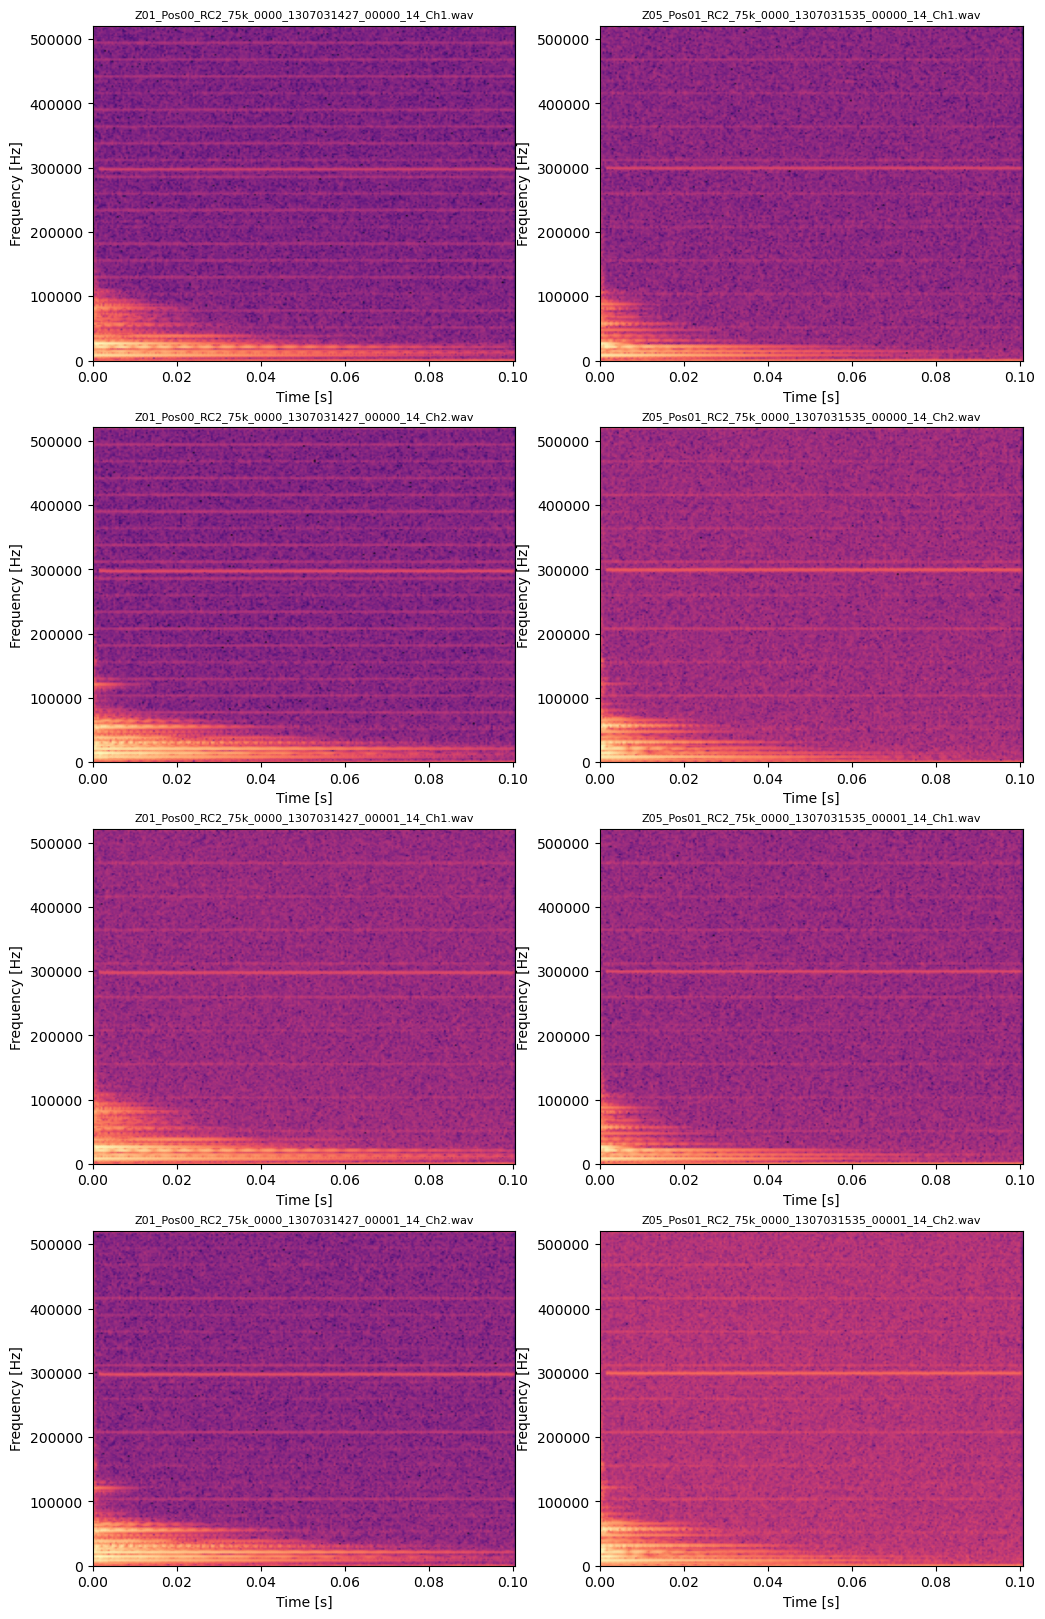

In [81]:
# The first cogwheel (Z01) is on the left, the second one (Z05) is on the right


fig, ax = plt.subplots(nrows=4, ncols=2, figsize = (12, 20))
plot_spectrogram(md[0]['stft'], md[0]['fn'], ax[0, 0])
plot_spectrogram(md[4]['stft'], md[4]['fn'], ax[0, 1])
plot_spectrogram(md[1]['stft'], md[1]['fn'], ax[1, 0])
plot_spectrogram(md[5]['stft'], md[5]['fn'], ax[1, 1])
plot_spectrogram(md[2]['stft'], md[2]['fn'], ax[2, 0])
plot_spectrogram(md[6]['stft'], md[6]['fn'], ax[2, 1])
plot_spectrogram(md[3]['stft'], md[3]['fn'], ax[3, 0])
plot_spectrogram(md[7]['stft'], md[7]['fn'], ax[3, 1])



### Step 6. Interpretation

We can see that the second cogwheel Z05 has a few irregularities:
 - the dominant peak at around 30000 Hz is almost doubled on spectrograms 2 and 4;
 - the subharmonic at 15000 Hz is unusually long and is comparable to the dominant peak
 - this is indicative of a "muddier" sound

Therefore, Z05 appears to be faulty